=== PHASE 1: LOADING DATA ===
Dataset successfully loaded!
Data dimensions: 1338 rows, 7 columns

--- First 5 Rows of Data ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


=== PHASE 2: CLEANING DATA ===
Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows found: 1
Duplicates successfully removed.
Categorical columns optimized.

=== PHASE 3: DESCRIPTIVE STATISTICS ===
--- Numerical Feature Summaries ---
           age      bmi  children   charges
count  1337.00  1337.00   1337.00   1337.00
mean     39.22    30.66      1.10  13279.12
std      1

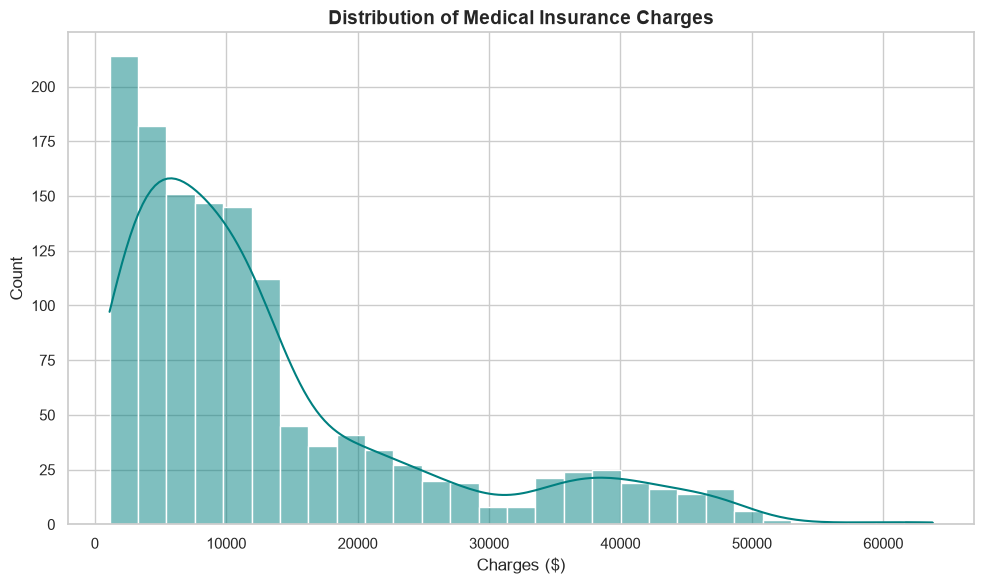

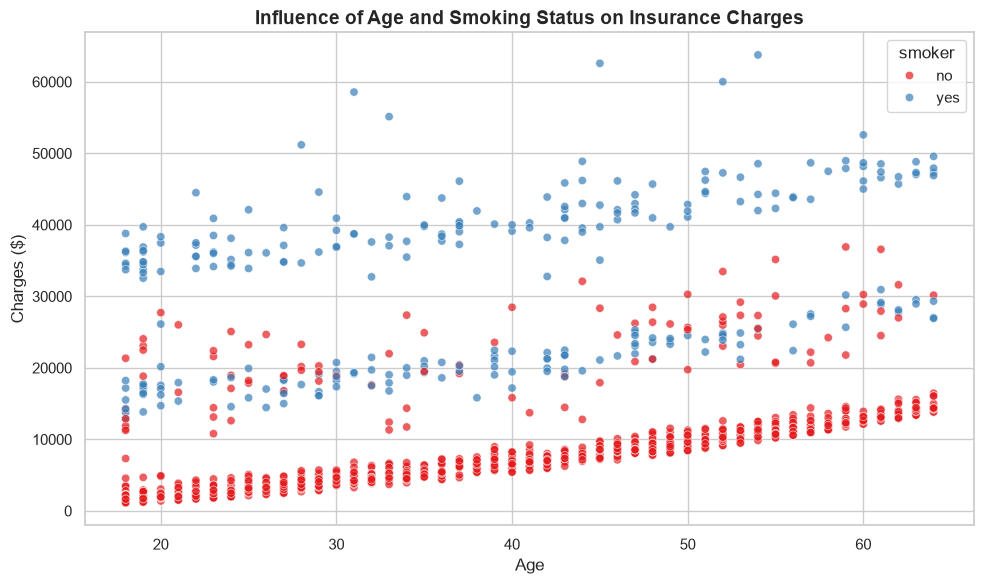

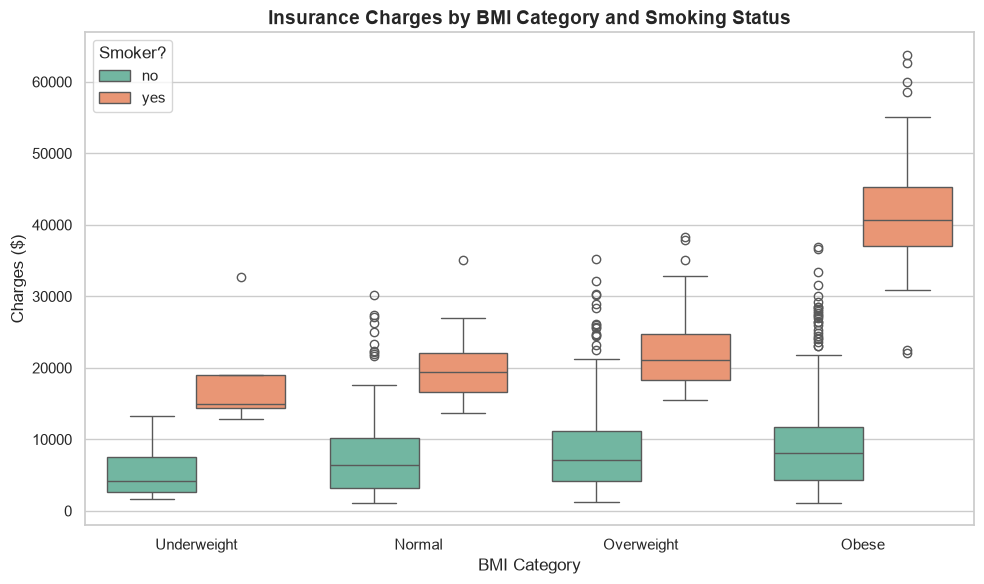

=== PHASE 5: CORRELATION ANALYSIS ===


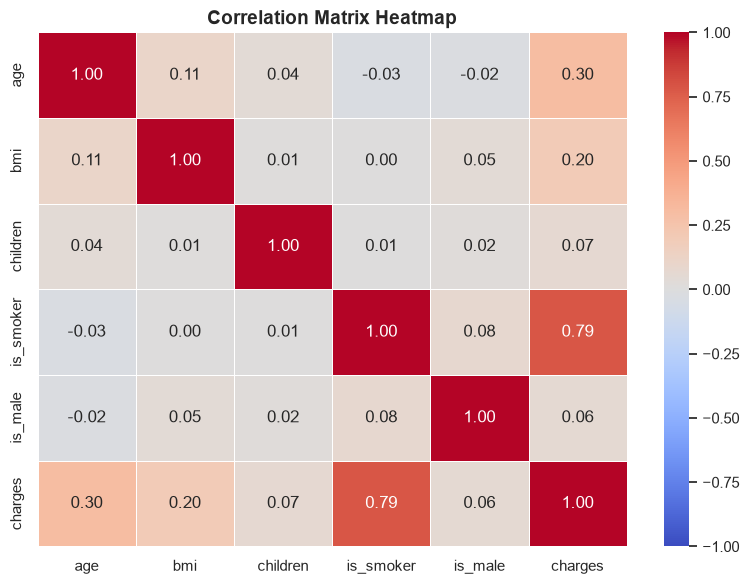

--- Correlation Coefficients Relative to Charges ---
charges      1.0000
is_smoker    0.7872
age          0.2983
bmi          0.1984
children     0.0674
is_male      0.0580
Name: charges, dtype: float64

=== EDA PROJECT ANALYSIS COMPLETE ===


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# PHASE 1: ENVIRONMENT SETUP & DATA LOADING
# ==========================================
print("=== PHASE 1: LOADING DATA ===")
# Set visual style for Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset directly from a reliable open-source URL
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)

print("Dataset successfully loaded!")
print(f"Data dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("--- First 5 Rows of Data ---")
print(df.head())
print("\n")

# ==========================================
# PHASE 2: DATA CLEANING & PREPROCESSING
# ==========================================
print("=== PHASE 2: CLEANING DATA ===")
# 1. Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# 2. Check and handle duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates successfully removed.")

# 3. Optimize data types for categorical analysis
categorical_cols = ['sex', 'smoker', 'region']
for col in categorical_cols:
    df[col] = df[col].astype('category')
print("Categorical columns optimized.\n")

# ==========================================
# PHASE 3: DESCRIPTIVE STATISTICS
# ==========================================
print("=== PHASE 3: DESCRIPTIVE STATISTICS ===")
print("--- Numerical Feature Summaries ---")
print(df.describe().round(2))

print("\n--- Categorical Feature Summaries ---")
print(df.describe(include=['category']))

print("\n--- Proportion of Smokers vs Non-Smokers ---")
print(df['smoker'].value_counts(normalize=True).round(2))
print("\n")

# ==========================================
# PHASE 4: DATA VISUALIZATION
# ==========================================
print("=== PHASE 4: GENERATING VISUALIZATIONS ===")

# Plot 1: Target Variable Distribution (Charges)
plt.figure(1)
sns.histplot(df['charges'], kde=True, color='teal')
plt.title('Distribution of Medical Insurance Charges', fontsize=14, fontweight='bold')
plt.xlabel('Charges ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()

# Plot 2: Scatter Plot (Age vs Charges colored by Smoking Status)
plt.figure(2)
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.7, palette='Set1')
plt.title('Influence of Age and Smoking Status on Insurance Charges', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.tight_layout()

# Plot 3: Box Plot (BMI Segments vs Charges colored by Smoking Status)
# Creating a temporary BMI category just for clean visualization bins
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 100], 
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

plt.figure(3)
sns.boxplot(x='bmi_category', y='charges', hue='smoker', data=df, palette='Set2')
plt.title('Insurance Charges by BMI Category and Smoking Status', fontsize=14, fontweight='bold')
plt.xlabel('BMI Category', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.legend(title='Smoker?')
plt.tight_layout()

# Show the plots created so far
plt.show()

# ==========================================
# PHASE 5: CORRELATION ANALYSIS
# ==========================================
print("=== PHASE 5: CORRELATION ANALYSIS ===")
# Create a copy to convert categorical text to numbers for correlation tracking
df_encoded = df.copy()
df_encoded['is_smoker'] = df_encoded['smoker'].cat.codes
df_encoded['is_male'] = df_encoded['sex'].cat.codes

# Compute the correlation matrix
corr_matrix = df_encoded[['age', 'bmi', 'children', 'is_smoker', 'is_male', 'charges']].corr()

# Plot the Heatmap
plt.figure(4, figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("--- Correlation Coefficients Relative to Charges ---")
print(corr_matrix['charges'].sort_values(ascending=False).round(4))
print("\n=== EDA PROJECT ANALYSIS COMPLETE ===")
